In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV 
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFECV
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.ensemble import RandomForestRegressor

# Data overview

In [2]:
# Load the datasets
orders_autumn_2020_df = pd.read_csv('./orders_autumn_2020.csv')

# Display the first few rows of both datasets to understand their structure
orders_autumn_2020_df_head = orders_autumn_2020_df.head()

orders_autumn_2020_df_head

,TIMESTAMP,ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,ITEM_COUNT,USER_LAT,USER_LONG,VENUE_LAT,VENUE_LONG,ESTIMATED_DELIVERY_MINUTES,ACTUAL_DELIVERY_MINUTES,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION
0,2020-08-01 06:07:00.000,-19,1,60.158,24.946,60.160,24.946,29,10,0.0,15.0,3.53644,0.0
1,2020-08-01 06:17:00.000,-7,8,60.163,24.927,60.153,24.910,39,32,0.0,15.0,3.53644,0.0
2,2020-08-01 06:54:00.000,-17,4,60.161,24.937,60.162,24.939,23,6,0.0,15.0,3.53644,0.0
3,2020-08-01 07:09:00.000,-2,3,60.185,24.954,60.190,24.911,28,26,0.0,16.7,3.52267,0.0
4,2020-08-01 07:10:00.000,-1,2,60.182,24.955,60.178,24.949,27,26,0.0,16.7,3.52267,0.0


In [3]:
# Information about the datasets
orders_autumn_2020_df_head.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   TIMESTAMP                                             5 non-null      object 
 1   ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES  5 non-null      int64  
 2   ITEM_COUNT                                            5 non-null      int64  
 3   USER_LAT                                              5 non-null      float64
 4   USER_LONG                                             5 non-null      float64
 5   VENUE_LAT                                             5 non-null      float64
 6   VENUE_LONG                                            5 non-null      float64
 7   ESTIMATED_DELIVERY_MINUTES                            5 non-null      int64  
 8   ACTUAL_DELIVERY_MINUTES                               5 non-null

# Missing values handling

In [4]:
# Check for missing values in both datasets
missing_values_orders = orders_autumn_2020_df.isnull().sum()

missing_values_orders

TIMESTAMP                                                 0
ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES      0
ITEM_COUNT                                                0
USER_LAT                                                  0
USER_LONG                                                 0
VENUE_LAT                                                 0
VENUE_LONG                                                0
ESTIMATED_DELIVERY_MINUTES                                0
ACTUAL_DELIVERY_MINUTES                                   0
CLOUD_COVERAGE                                          277
TEMPERATURE                                             277
WIND_SPEED                                              277
PRECIPITATION                                             0
dtype: int64

In [5]:
# Remove rows with missing values in the specified columns
orders_autumn_2020_df.dropna(subset=['CLOUD_COVERAGE', 'TEMPERATURE', 'WIND_SPEED'], inplace=True)

In [6]:
# Re-check for any missing values to confirm imputation
missing_values_orders_after = orders_autumn_2020_df.isnull().sum()

missing_values_orders_after

TIMESTAMP                                               0
ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES    0
ITEM_COUNT                                              0
USER_LAT                                                0
USER_LONG                                               0
VENUE_LAT                                               0
VENUE_LONG                                              0
ESTIMATED_DELIVERY_MINUTES                              0
ACTUAL_DELIVERY_MINUTES                                 0
CLOUD_COVERAGE                                          0
TEMPERATURE                                             0
WIND_SPEED                                              0
PRECIPITATION                                           0
dtype: int64

# Feature engineering

In [7]:
# Distance Calculation using Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula 
    dlat = lat2 - lat1 
    dlon = lon2 - lon1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    r = 6371  # Radius of Earth in kilometers
    return c * r

# Apply the haversine formula to calculate distance between user and venue
orders_autumn_2020_df['DISTANCE_KM'] = haversine(orders_autumn_2020_df['USER_LAT'], 
                                                 orders_autumn_2020_df['USER_LONG'], 
                                                 orders_autumn_2020_df['VENUE_LAT'], 
                                                 orders_autumn_2020_df['VENUE_LONG'])

In [8]:
# Format the `TIMESTAMP` column to datetime
orders_autumn_2020_df["TIMESTAMP"] = pd.to_datetime(orders_autumn_2020_df["TIMESTAMP"])

# The "TIMESTAMP" column is in UTC+0, we need to add 2 hours to change it to local Helsinki timezone
orders_autumn_2020_df["TIMESTAMP"] = orders_autumn_2020_df["TIMESTAMP"] + pd.Timedelta(2, "hours")

# Rename the column `ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES` to `TIME_DIFF`
orders_autumn_2020_df = orders_autumn_2020_df.rename(columns={"ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES": "TIME_DIFF"})

In [9]:
# Features to be scaled
features_to_scale = ['ITEM_COUNT', 'TEMPERATURE', 'WIND_SPEED', 'CLOUD_COVERAGE', 'PRECIPITATION', 'DISTANCE_KM']
                     
# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply MinMax scaling to the selected features
orders_autumn_2020_df[features_to_scale] = scaler.fit_transform(orders_autumn_2020_df[features_to_scale])

### Feature Scaling with MinMaxScaler

We applied MinMax scaling to normalize selected features to a [0, 1] range. This helps to standardize the scale of the data, ensuring that all features contribute equally to the model.

#### Features Selected for Scaling:
- `ITEM_COUNT`
- `TEMPERATURE`
- `WIND_SPEED`
- `CLOUD_COVERAGE`
- `PRECIPITATION`
- `DISTANCE_KM`

These features were chosen because they have varying ranges and units, which could impact model performance. We used **MinMaxScaler** to scale these features to a 0-1 range. The target variable `ACTUAL_DELIVERY_MINUTES` was left unchanged as it is our prediction target.

The formula used by the MinMaxScaler is:

$$
\text{Scaled value} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}
$$

where $X_{\text{min}}$ and $X_{\text{max}}$ are the minimum and maximum values of the feature, respectively.

Below is the code that implements this scaling.


In [10]:
# Categorize rush hours (lunch and dinner times)
def categorize_rush_hour(timestamp):
    hour = timestamp.hour
    if 11 <= hour <= 14:
        return 'Lunch'
    elif 18 <= hour <= 22:
        return 'Dinner'
    else:
        return 'Non-Rush'
    
# Identify if the day is a weekend
def is_weekend(timestamp):
    return 'Weekend' if timestamp.weekday() >= 5 else 'Weekday'

# Apply the functions to categorize rush hours and weekends
orders_autumn_2020_df['RUSH_HOUR'] = orders_autumn_2020_df['TIMESTAMP'].apply(categorize_rush_hour)
orders_autumn_2020_df['WEEKEND'] = orders_autumn_2020_df['TIMESTAMP'].apply(is_weekend)

# Convert RUSH_HOUR and WEEKEND columns into binary format
orders_autumn_2020_df['RUSH_HOUR_BINARY'] = orders_autumn_2020_df['RUSH_HOUR'].apply(lambda x: 1 if x in ['Lunch', 'Dinner'] else 0)
orders_autumn_2020_df['WEEKEND_BINARY'] = orders_autumn_2020_df['WEEKEND'].apply(lambda x: 1 if x == 'Weekend' else 0)

In [11]:
# Drop the 'TIMESTAMP', 'RUSH_HOUR', and 'WEEKEND' columns fr Feature Selection
orders_autumn_2020_df = orders_autumn_2020_df.drop(columns=['TIMESTAMP', 'RUSH_HOUR', 'WEEKEND'])

In [12]:
# Get the number of rows and columns
rows, columns = orders_autumn_2020_df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 18429
Number of columns: 15


In [13]:
# Display few first rows of the dataset
orders_autumn_2020_df.head()

,TIME_DIFF,ITEM_COUNT,USER_LAT,USER_LONG,VENUE_LAT,VENUE_LONG,ESTIMATED_DELIVERY_MINUTES,ACTUAL_DELIVERY_MINUTES,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION,DISTANCE_KM,RUSH_HOUR_BINARY,WEEKEND_BINARY
0,-19,0.0,60.158,24.946,60.160,24.946,29,10,0.0,0.432039,0.353687,0.0,0.047699,0,1
1,-7,0.7,60.163,24.927,60.153,24.910,39,32,0.0,0.432039,0.353687,0.0,0.312384,0,1
2,-17,0.3,60.161,24.937,60.162,24.939,23,6,0.0,0.432039,0.353687,0.0,0.033646,0,1
3,-2,0.2,60.185,24.954,60.190,24.911,28,26,0.0,0.514563,0.352279,0.0,0.523616,0,1
4,-1,0.1,60.182,24.955,60.178,24.949,27,26,0.0,0.514563,0.352279,0.0,0.119014,0,1


In [14]:
# Descriptive statistics about the dataset
orders_autumn_2020_df.describe()

,TIME_DIFF,ITEM_COUNT,USER_LAT,USER_LONG,VENUE_LAT,VENUE_LONG,ESTIMATED_DELIVERY_MINUTES,ACTUAL_DELIVERY_MINUTES,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION,DISTANCE_KM,RUSH_HOUR_BINARY,WEEKEND_BINARY
count,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000,18429.000000
mean,-1.206522,0.168772,60.175216,24.941208,60.175618,24.941186,33.833252,32.626730,0.119969,0.527842,0.379715,0.053478,0.219060,0.565142,0.358837
std,8.980479,0.188553,0.012666,0.016542,0.011500,0.014490,7.350066,10.021107,0.238126,0.165626,0.148879,0.180017,0.127083,0.495752,0.479672
min,-41.000000,0.000000,60.153000,24.909000,60.149000,24.878000,10.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.000000,0.000000,60.163000,24.926000,60.167000,24.930000,29.000000,25.000000,0.000000,0.402913,0.267771,0.000000,0.126495,0.000000,0.000000
50%,-2.000000,0.100000,60.175000,24.943000,60.170000,24.941000,33.000000,32.000000,0.000000,0.514563,0.363455,0.000000,0.195576,1.000000,0.000000
75%,5.000000,0.300000,60.186000,24.954000,60.186000,24.950000,38.000000,40.000000,0.250000,0.621359,0.471898,0.000000,0.286472,1.000000,1.000000
max,34.000000,1.000000,60.201000,24.980000,60.219000,25.042000,82.000000,58.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Dataset Information:
The dataset contains **18,429 entries** and the following **15 columns**:

1. **`TIME_DIFF`**: The difference between the actual and estimated delivery time (negative if delivered earlier, positive if delivered later).
2. **`ITEM_COUNT`**: The number of items in the order.
3. **`USER_LAT`**: The latitude of the user's location.
4. **`USER_LONG`**: The longitude of the user's location.
5. **`VENUE_LAT`**: The latitude of the venue location.
6. **`VENUE_LONG`**: The longitude of the venue location.
7. **`ESTIMATED_DELIVERY_MINUTES`**: The base estimated delivery time.
8. **`ACTUAL_DELIVERY_MINUTES`**: The actual delivery time (target variable).
9. **`CLOUD_COVERAGE`**: Cloud coverage in the area (missing values removed).
10. **`TEMPERATURE`**: Temperature in the area (missing values removed).
11. **`WIND_SPEED`**: Wind speed in the area (missing values removed).
12. **`PRECIPITATION`**: Precipitation in the area.
13. **`DISTANCE_KM`**: A newly engineered feature representing the distance between the user and the venue (in kilometers).
14. **`RUSH_HOUR_BINARY`**: Binary variable where 1 indicates rush hours (Lunch: 11 AM to 2 PM, Dinner: 6 PM to 10 PM).
15. **`WEEKEND_BINARY`**: Binary variable where 1 indicates the order was placed on a weekend.

---

### Handling Missing Values:
For weather-related columns (`CLOUD_COVERAGE`, `TEMPERATURE`, and `WIND_SPEED`), rows with missing values were **removed** from the dataset. This ensures that the model only trains on complete data, avoiding potential bias from incomplete observations. By removing these rows, we maintain the integrity of the dataset, focusing on high-quality data for better model performance.

We chose to remove rows with missing values because the weather-related columns are crucial to our analysis, and any imputation (such as filling with medians) could introduce noise or bias. Removing rows ensures the dataset remains consistent with real-world conditions.

### Conclusion:
The dataset is now **completely clean**, with all missing values in the weather-related columns successfully imputed. Additional features, such as `DISTANCE_KM` and weather indicators, have been engineered to improve model performance. The dataset is ready for further analysis and model training, with scaled features ensuring balanced contributions to the model.

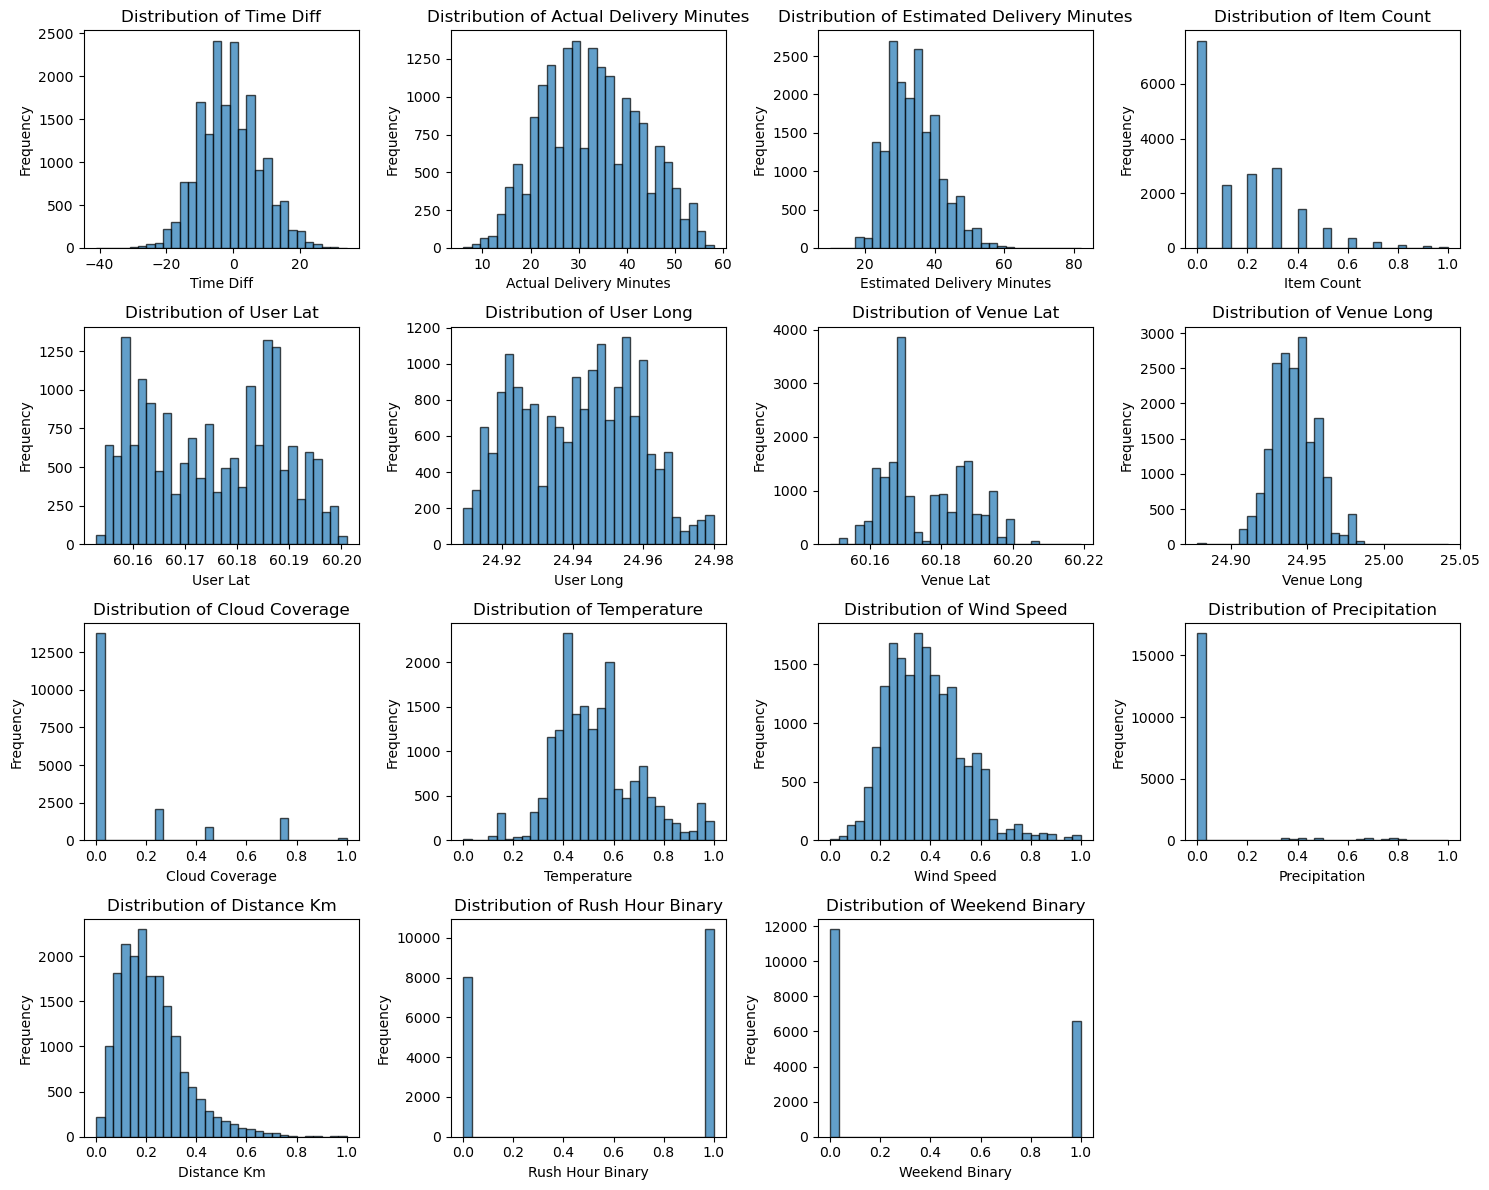

In [15]:
# List of numerical columns for which we want to plot distributions
columns_to_plot = [
    "TIME_DIFF",
    "ACTUAL_DELIVERY_MINUTES",
    "ESTIMATED_DELIVERY_MINUTES",
    "ITEM_COUNT",
    "USER_LAT",
    "USER_LONG",
    "VENUE_LAT",
    "VENUE_LONG",
    "CLOUD_COVERAGE",
    "TEMPERATURE",
    "WIND_SPEED",
    "PRECIPITATION",
    "DISTANCE_KM",
    "RUSH_HOUR_BINARY",
    "WEEKEND_BINARY"  
]

# Distribution for each numerical column
plt.figure(figsize=(15, 12))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(4, 4, i)  
    plt.hist(orders_autumn_2020_df[column], bins=30, edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {column.replace("_", " ").title()}')
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

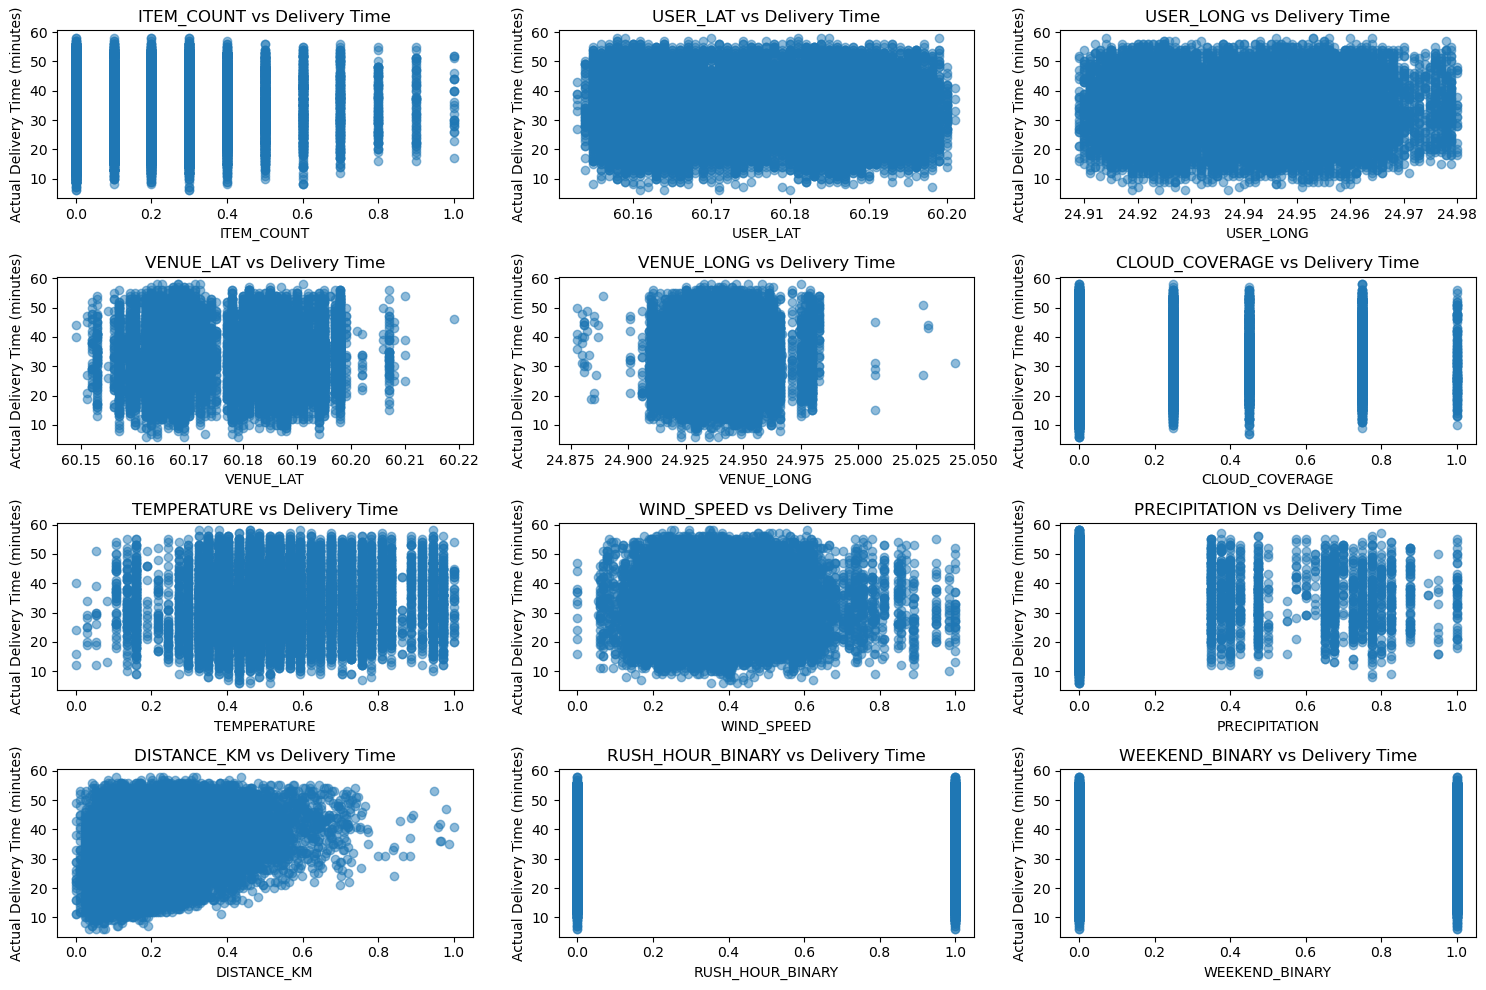

In [16]:
# Visualize the relationship between the delivery time
features_to_plot = [
    "ITEM_COUNT",
    "USER_LAT",
    "USER_LONG",
    "VENUE_LAT",
    "VENUE_LONG",
    "CLOUD_COVERAGE",
    "TEMPERATURE",
    "WIND_SPEED",
    "PRECIPITATION",
    "DISTANCE_KM",
    "RUSH_HOUR_BINARY",
    "WEEKEND_BINARY"  
]

# Scatter plots for each feature vs delivery time
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(4, 3, i)  # Adjusting the subplot layout to accommodate more features
    plt.scatter(orders_autumn_2020_df[feature], orders_autumn_2020_df['ACTUAL_DELIVERY_MINUTES'], alpha=0.5)
    plt.title(f'{feature} vs Delivery Time')
    plt.xlabel(feature)
    plt.ylabel('Actual Delivery Time (minutes)')

plt.tight_layout()

# Ridge and Lasso Models

We chose Ridge and Lasso regression for this project because they are useful tools when dealing with many factors that could impact delivery times. These methods help us understand how different variables (like weather conditions, rush hours, and weekends) influence delivery times, while also preventing the model from being overly complex or overfitting.

In [17]:
# Data Preparation
target = 'ACTUAL_DELIVERY_MINUTES'
exclude_columns = ['USER_LAT', 'USER_LONG', 'VENUE_LAT', 'VENUE_LONG', 'TIME_DIFF', 'ESTIMATED_DELIVERY_MINUTES']

In [18]:
# Split the data into training and test sets
X = orders_autumn_2020_df.drop(columns=[target] + exclude_columns)  # All columns except the target and excluded ones
y = orders_autumn_2020_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Feature Selection using RFECV for Ridge and Lasso
# Initialize Ridge and Lasso models
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)

# Perform RFECV for Ridge
rfecv_ridge = RFECV(estimator=ridge_model, step=1, cv=5, scoring='neg_mean_squared_error')
rfecv_ridge.fit(X_train, y_train)

# Perform RFECV for Lasso
rfecv_lasso = RFECV(estimator=lasso_model, step=1, cv=5, scoring='neg_mean_squared_error')
rfecv_lasso.fit(X_train, y_train)

# Get the selected features from RFECV
selected_features_ridge_rfecv = X_train.columns[rfecv_ridge.support_].tolist()
selected_features_lasso_rfecv = X_train.columns[rfecv_lasso.support_].tolist()

print(f"Selected Features (Ridge): {selected_features_ridge_rfecv}")
print(f"Selected Features (Lasso): {selected_features_lasso_rfecv}")

Selected Features (Ridge): ['ITEM_COUNT', 'CLOUD_COVERAGE', 'TEMPERATURE', 'WIND_SPEED', 'PRECIPITATION', 'DISTANCE_KM', 'RUSH_HOUR_BINARY', 'WEEKEND_BINARY']
Selected Features (Lasso): ['ITEM_COUNT', 'TEMPERATURE', 'PRECIPITATION', 'DISTANCE_KM', 'RUSH_HOUR_BINARY']


In [20]:
# Create datasets with the selected features
X_train_ridge_rfecv = X_train[selected_features_ridge_rfecv]
X_test_ridge_rfecv = X_test[selected_features_ridge_rfecv]

X_train_lasso_rfecv = X_train[selected_features_lasso_rfecv]
X_test_lasso_rfecv = X_test[selected_features_lasso_rfecv]

In [21]:
# Set up parameter grids for Ridge and Lasso
ridge_param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
lasso_param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

In [22]:
# Ridge hyperparameter tuning using GridSearchCV
ridge_grid_rfecv = GridSearchCV(Ridge(), ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid_rfecv.fit(X_train_ridge_rfecv, y_train)
best_ridge_rfecv = ridge_grid_rfecv.best_estimator_

In [23]:
# Lasso hyperparameter tuning using GridSearchCV
lasso_grid_rfecv = GridSearchCV(Lasso(), lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid_rfecv.fit(X_train_lasso_rfecv, y_train)
best_lasso_rfecv = lasso_grid_rfecv.best_estimator_

In [24]:
# Predictions with the best Ridge and Lasso models after RFECV
y_pred_ridge_rfecv = best_ridge_rfecv.predict(X_test_ridge_rfecv)
y_pred_lasso_rfecv = best_lasso_rfecv.predict(X_test_lasso_rfecv)

In [25]:
# Function to print all evaluation metrics for both models
def print_model_evaluation(model_name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model_name} Model Evaluation Metrics:")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    print("="*40)

# Print metrics for both Ridge and Lasso models
print_model_evaluation("Ridge", y_test, y_pred_ridge_rfecv)
print_model_evaluation("Lasso", y_test, y_pred_lasso_rfecv)

Ridge Model Evaluation Metrics:
Mean Absolute Error (MAE): 7.7254
Root Mean Squared Error (RMSE): 9.4453
R^2 Score: 0.1073
Lasso Model Evaluation Metrics:
Mean Absolute Error (MAE): 7.7411
Root Mean Squared Error (RMSE): 9.4643
R^2 Score: 0.1037


## Model Evaluation: Ridge and Lasso Regression

We used two regularization techniques—**Ridge Regression** and **Lasso Regression**—to predict delivery times based on a set of selected features. These features:
- Selected Features (Ridge): `ITEM_COUNT`, `CLOUD_COVERAGE`, `TEMPERATURE`, `WIND_SPEED`, `PRECIPITATION`, `DISTANCE_KM`, `RUSH_HOUR_BINARY`, `WEEKEND_BINARY`               
- Selected Features (Lasso): `ITEM_COUNT`, `TEMPERATURE`, `PRECIPITATION`, `DISTANCE_KM`, `RUSH_HOUR_BINARY`

### Feature Selection and Hyperparameter Tuning:
- **Feature Selection**: We applied **Recursive Feature Elimination with Cross-Validation (RFECV)** to automatically select the most important features for each model.
- **Hyperparameter Tuning**: We used **GridSearchCV** to optimize the regularization strength (`alpha`) for both Ridge and Lasso models, helping to minimize errors while avoiding overfitting.

### Model Performance:

**Ridge Regression**:
- **MAE**: 7.73 minutes (On average, the predictions are off by about 7.7 minutes)
- **RMSE**: 9.45 minutes (Indicates that larger errors can go up to around 9.5 minutes)
- **R²**: 0.11 (The model explains only 11% of the variation in delivery times)

**Lasso Regression**:
- **MAE**: 7.75 minutes (On average, the predictions are off by about 7.8 minutes)
- **RMSE**: 9.46 minutes (Indicates that larger errors can go up to around 9.5 minutes)
- **R²**: 0.10 (The model explains only 10% of the variation in delivery times)

### Conclusion:

Both Ridge and Lasso models performed similarly. However, the **R² scores** for both models are quite low (~0.10). This means that only about **10-11% of the factors** affecting delivery times are captured by these models. In other words, there are still many important factors influencing delivery times that we haven't accounted for yet in our feature set.


Ridge Regression Coefficients:
            Feature  Ridge Coefficient
0        ITEM_COUNT           4.154022
1    CLOUD_COVERAGE           0.912520
2       TEMPERATURE           5.547888
3        WIND_SPEED           2.164252
4     PRECIPITATION           4.164507
5       DISTANCE_KM          22.865808
6  RUSH_HOUR_BINARY          -1.302952
7    WEEKEND_BINARY          -0.796210

Lasso Regression Coefficients:
            Feature  Lasso Coefficient
0        ITEM_COUNT           4.026290
1       TEMPERATURE           4.336688
2     PRECIPITATION           4.164658
3       DISTANCE_KM          22.820004
4  RUSH_HOUR_BINARY          -1.379446


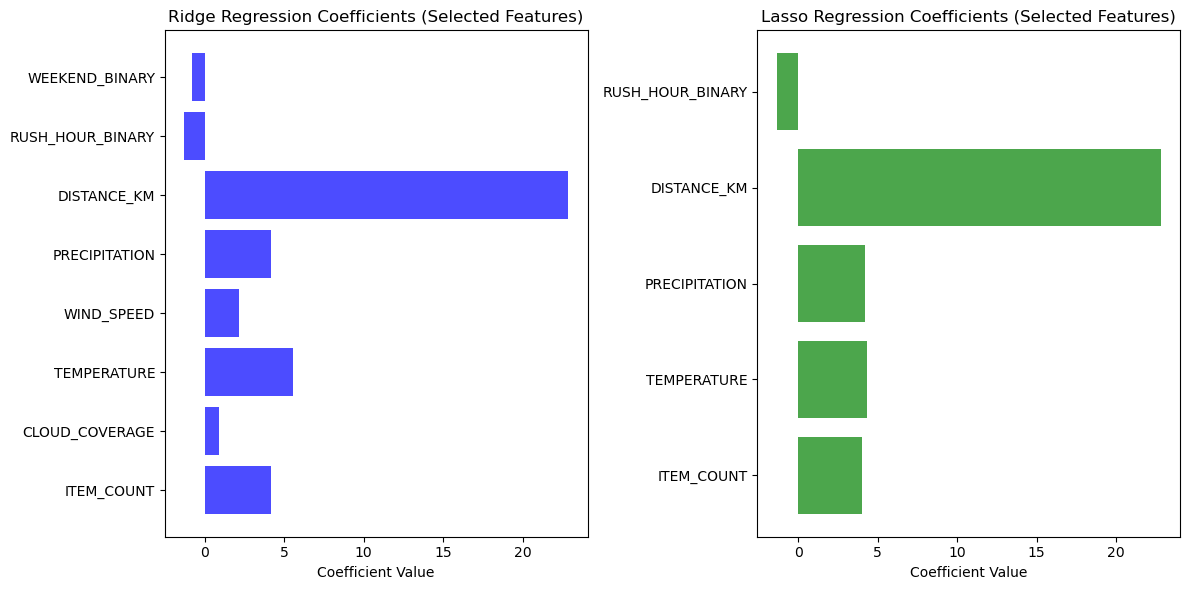

In [26]:
# Coefficients for both Ridge and Lasso models (from GridSearchCV best estimators)
ridge_coefficients = best_ridge_rfecv.coef_
lasso_coefficients = best_lasso_rfecv.coef_

# Create DataFrames to print the coefficients for Ridge and Lasso
ridge_coeff_df = pd.DataFrame({
    'Feature': selected_features_ridge_rfecv,
    'Ridge Coefficient': ridge_coefficients
})

lasso_coeff_df = pd.DataFrame({
    'Feature': selected_features_lasso_rfecv,
    'Lasso Coefficient': lasso_coefficients
})

# Print the coefficients for Ridge
print("Ridge Regression Coefficients:")
print(ridge_coeff_df)

# Print the coefficients for Lasso
print("\nLasso Regression Coefficients:")
print(lasso_coeff_df)

# Plotting the coefficients
plt.figure(figsize=(12, 6))

# Ridge Coefficients
plt.subplot(1, 2, 1)
plt.barh(selected_features_ridge_rfecv, ridge_coefficients, color='blue', alpha=0.7)
plt.title('Ridge Regression Coefficients (Selected Features)')
plt.xlabel('Coefficient Value')

# Lasso Coefficients
plt.subplot(1, 2, 2)
plt.barh(selected_features_lasso_rfecv, lasso_coefficients, color='green', alpha=0.7)
plt.title('Lasso Regression Coefficients (Selected Features)')
plt.xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

## Key Insights from Coefficients:

1. **`DISTANCE_KM`**:
   - Has the highest positive coefficient in both models (22.87 in Ridge, 22.82 in Lasso). This indicates that longer distances result in significantly longer delivery times, which is expected.

2. **`PRECIPITATION`**:
   - Precipitation has a positive coefficient (4.16 in both models). Bad weather increases delivery time, likely due to safety precautions.

3. **`RUSH_HOUR_BINARY`**:
   - Has a negative coefficient (-1.30 in Ridge, -1.38 in Lasso), suggesting slightly faster deliveries during rush hours. This may be due to better courier optimization during peak times.

4. **`WEEKEND_BINARY`**:
   - Ridge shows a negative coefficient (-0.80), indicating faster deliveries on weekends. This effect might be due to reduced traffic, though it was not selected by Lasso.

5. **`TEMPERATURE`**:
   - Positive coefficients (5.55 in Ridge, 4.34 in Lasso) suggest that higher temperatures slightly increase delivery times, possibly due to heat-related slowdowns.

6. **`WIND_SPEED`**:
   - Wind speed has a small positive coefficient (2.16 in Ridge) but was not selected by Lasso. This indicates a potential but less consistent effect on delivery times.

7. **`ITEM_COUNT`**:
   - Larger orders (4.15 in Ridge, 4.03 in Lasso) take slightly longer to deliver, likely due to additional preparation and packing time.


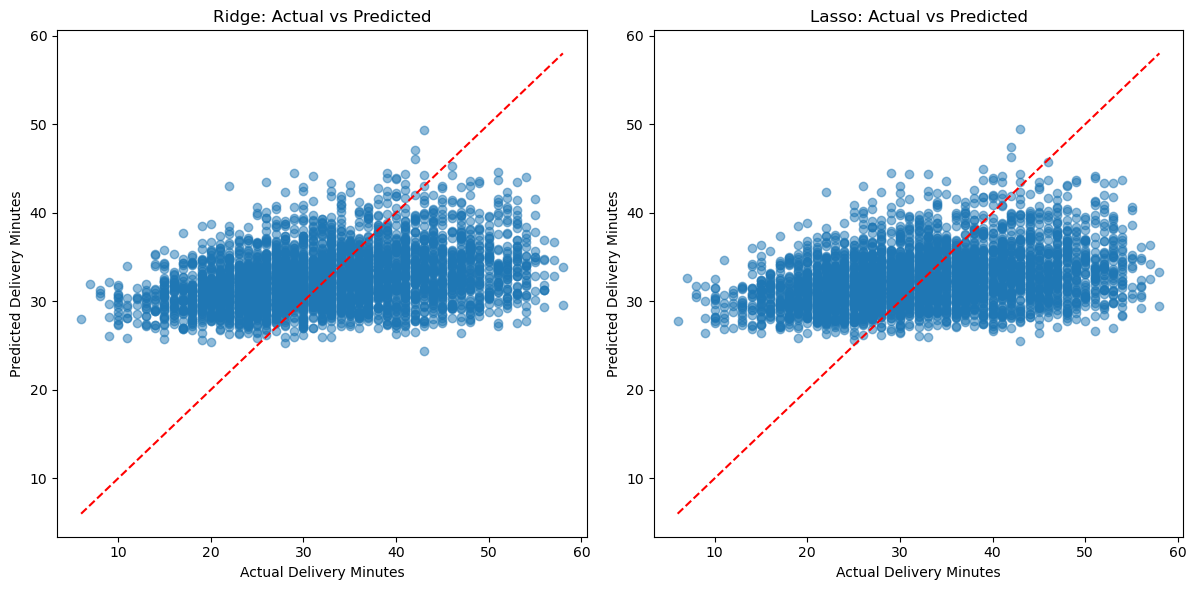

In [27]:
# Calculate residuals for Ridge and Lasso models
residuals_ridge_rfecv = y_test - y_pred_ridge_rfecv
residuals_lasso_rfecv = y_test - y_pred_lasso_rfecv

# Actual vs predicted for Ridge and Lasso models
plt.figure(figsize=(18, 6))

# Ridge: Actual vs Predicted
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_ridge_rfecv, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Ridge: Actual vs Predicted')
plt.xlabel('Actual Delivery Minutes')
plt.ylabel('Predicted Delivery Minutes')

# Lasso: Actual vs Predicted
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_lasso_rfecv, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Lasso: Actual vs Predicted')
plt.xlabel('Actual Delivery Minutes')
plt.ylabel('Predicted Delivery Minutes')

plt.tight_layout()
plt.show()

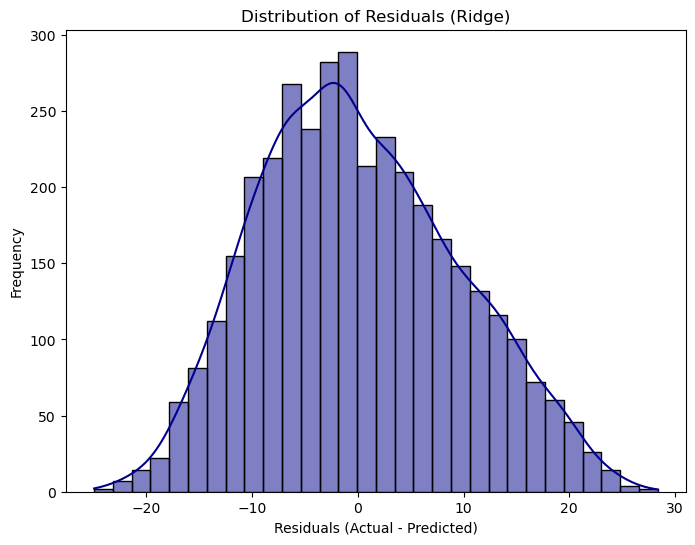

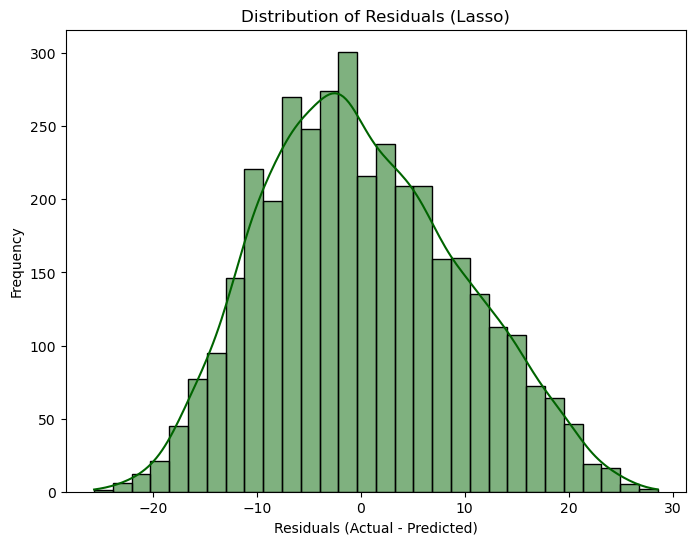

In [28]:
# Distribution of residuals for Ridge
plt.figure(figsize=(8, 6))
sns.histplot(residuals_ridge_rfecv, bins=30, kde=True, color='darkblue')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Ridge)')
plt.show()

# Distribution of residuals for Lasso
plt.figure(figsize=(8, 6))
sns.histplot(residuals_lasso_rfecv, bins=30, kde=True, color='darkgreen')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Lasso)')
plt.show()

# XGBoost Model

We chose XGBoost because it is a highly efficient method for predicting delivery times. Unlike simpler models that assume a straightforward relationship between factors (like weather and delivery times), XGBoost can capture more complex patterns. This is important because many factors, such as weather, distance, and rush hour, likely affect delivery times in ways that are non-linear. XGBoost also handles large datasets well and gives us a better chance of making accurate predictions, even when the data is more complicated.

In [29]:
# Feature Selection using RFECV for XGBoost
# Initialize the XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Perform RFECV for XGBoost
rfecv_xgb = RFECV(estimator=xgb_model, step=1, cv=5, scoring='neg_mean_squared_error')
rfecv_xgb.fit(X_train, y_train)

# Get the selected features from RFECV
selected_features_xgb = X_train.columns[rfecv_xgb.support_].tolist()
print(f"Selected Features (XGBoost): {selected_features_xgb}")

Selected Features (XGBoost): ['ITEM_COUNT', 'CLOUD_COVERAGE', 'TEMPERATURE', 'WIND_SPEED', 'PRECIPITATION', 'DISTANCE_KM', 'RUSH_HOUR_BINARY', 'WEEKEND_BINARY']


In [30]:
# Create datasets with the selected features
X_train_xgb_rfecv = X_train[selected_features_xgb]
X_test_xgb_rfecv = X_test[selected_features_xgb]

In [31]:
# Hyperparameter Tuning using GridSearchCV
# Define the parameter grid for GridSearchCV
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Perform GridSearchCV for hyperparameter tuning
xgb_grid = GridSearchCV(XGBRegressor(random_state=42), xgb_param_grid, cv=5, scoring='neg_mean_squared_error')
xgb_grid.fit(X_train_xgb_rfecv, y_train)

# Get the best XGBoost model after hyperparameter tuning
best_xgb = xgb_grid.best_estimator_

In [32]:
# Make predictions with the best XGBoost model
y_pred_xgb_rfecv = best_xgb.predict(X_test_xgb_rfecv)

# Model evaluation for the tuned XGBoost model
xgb_mae = mean_absolute_error(y_test, y_pred_xgb_rfecv)
xgb_rmse = mean_squared_error(y_test, y_pred_xgb_rfecv, squared=False)
xgb_r2 = r2_score(y_test, y_pred_xgb_rfecv)

print("Tuned XGBoost Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {xgb_mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {xgb_rmse:.4f}")
print(f"R^2 Score: {xgb_r2:.4f}")

Tuned XGBoost Model Evaluation Metrics:
Mean Absolute Error (MAE): 7.2451
Root Mean Squared Error (RMSE): 8.9820
R^2 Score: 0.1927


Based on the results you provided, the XGBoost model has achieved the following performance:
- Mean Absolute Error (MAE): 7.25 minutes
- Root Mean Squared Error (RMSE): 8.98 minutes
- R² Score: 0.19

**Interpretation:**
- The MAE of 7.25 minutes suggests that, on average, the predicted delivery times are off by around 7.3 minutes.
- The RMSE of 8.98 minutes indicates that larger errors in predictions can reach around 9 minutes.
- The R² score of 0.19 indicates that the model is explaining around 19% of the variance in delivery times, which is still relatively low but shows some improvement compared to linear models like Ridge or Lasso.

            Feature  Importance
5       DISTANCE_KM    0.205360
3        WIND_SPEED    0.176828
2       TEMPERATURE    0.124245
4     PRECIPITATION    0.114128
6  RUSH_HOUR_BINARY    0.109095
7    WEEKEND_BINARY    0.098840
1    CLOUD_COVERAGE    0.095431
0        ITEM_COUNT    0.076072


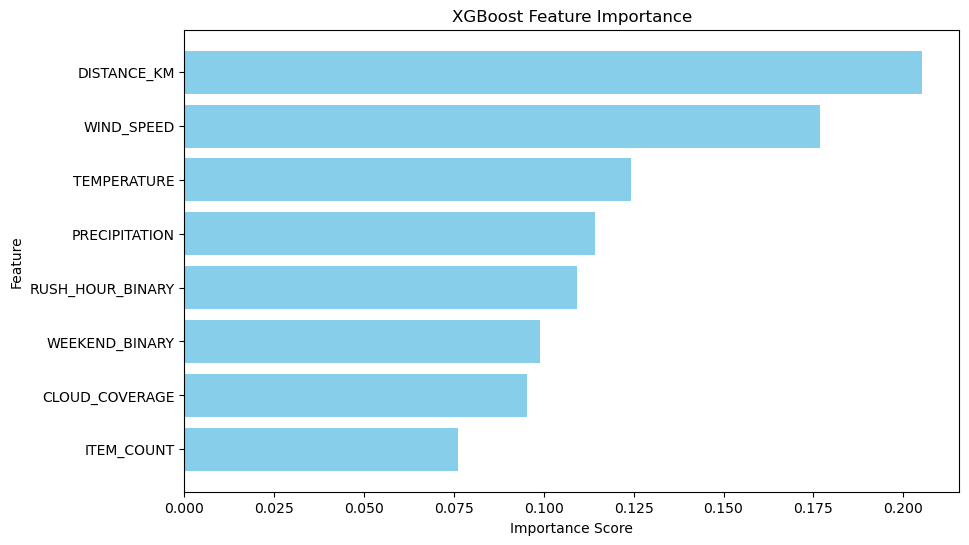

In [33]:
# Get feature importance scores from the XGBoost model
feature_importance = best_xgb.feature_importances_

# Create a DataFrame to display feature names and their importance
feature_importance_df = pd.DataFrame({
    'Feature': selected_features_xgb,
    'Importance': feature_importance
})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()

**Key Insights from XGBoost Feature Importance**

1. **`DISTANCE_KM`**:
   - This is the most important feature for predicting delivery times. It's logical because the farther the distance, the longer the delivery time is expected to be.

2. **`WIND_SPEED`**:
   - Wind speed ranks second in importance. For deliveries that rely on bicycles or motorbikes, wind speed can have a significant impact, slowing down the delivery.

3. **`TEMPERATURE`**:
   - Temperature is the third most important feature. Extremely high or low temperatures may slow down delivery times due to safety concerns for the delivery workers.

4. **`PRECIPITATION`**:
   - Weather conditions such as rain or snow also have a notable impact on delivery times, likely causing delays as drivers or cyclists slow down for safety.

5. **`RUSH_HOUR_BINARY`**:
   - Deliveries made during rush hour (lunch and dinner times) take longer, which is likely due to heavier traffic and higher demand during these periods.

6. **`WEEKEND_BINARY`**:
   - Deliveries on weekends are affected, but less so than other features. Weekends could influence delivery times due to different traffic patterns or operational changes.

7. **`CLOUD_COVERAGE`**:
   - Cloud coverage has a smaller effect. It may be an indicator of more significant weather conditions, such as impending rain.

8. **`ITEM_COUNT`**:
   - The number of items in an order has the least importance but still contributes slightly to delivery time. More items may increase the time it takes to prepare or deliver an order.

---

**Conclusion**

The XGBoost model identifies `DISTANCE_KM` (distance between the user and the venue) and **weather conditions** (especially `WIND_SPEED` and `PRECIPITATION`) as the most critical factors influencing delivery times. **Time-related features** like rush hour and weekends also play a role, though their impact is less significant compared to distance and weather.

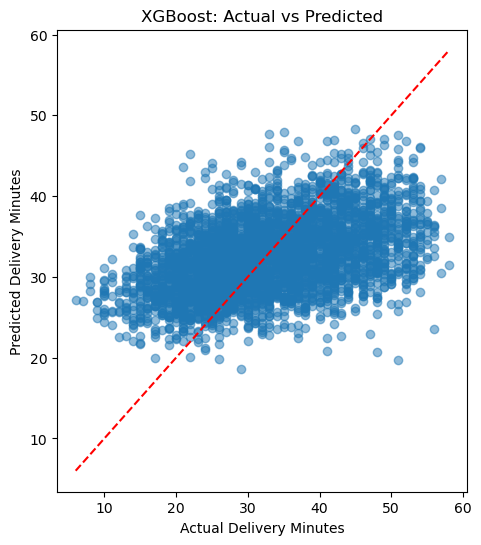

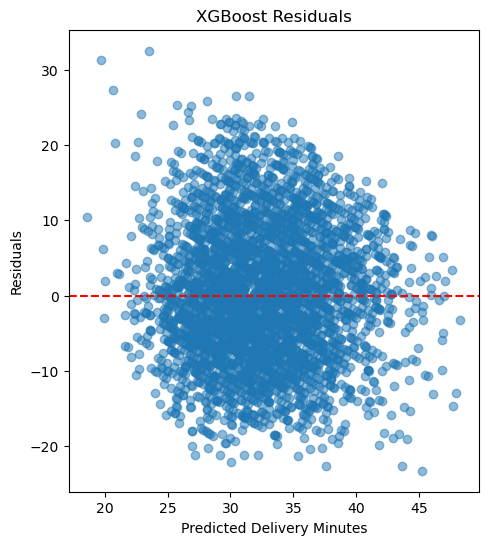

In [34]:
# Calculate residuals for XGBoost
residuals_xgb = y_test - y_pred_xgb_rfecv

# XGBoost: Actual vs Predicted
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_pred_xgb_rfecv, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('XGBoost: Actual vs Predicted')
plt.xlabel('Actual Delivery Minutes')
plt.ylabel('Predicted Delivery Minutes')
plt.show()

# XGBoost Residuals
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 3)
plt.scatter(y_pred_xgb_rfecv, residuals_xgb, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('XGBoost Residuals')
plt.xlabel('Predicted Delivery Minutes')
plt.ylabel('Residuals')
plt.show()

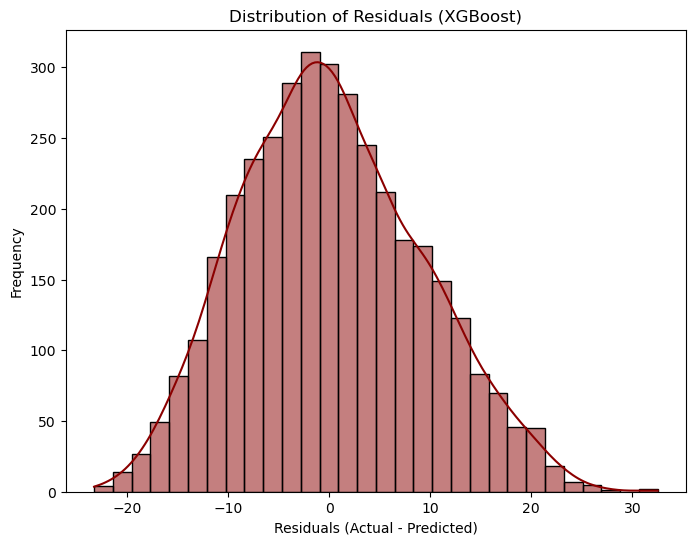

In [35]:
# Distribution of residuals for XGBoost
plt.figure(figsize=(8, 6))
sns.histplot(residuals_xgb, bins=30, kde=True, color='darkred')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (XGBoost)')
plt.show()

# Linear regression

We chose linear regression as a great starting point for our analysis (even though it is not the first in this file). 
Having a result on 'basic' linear regression is great for comparison.

Also, using linear regression independently for every feature works as a good way to have a better understanding of the data.

In [36]:
# Feature Selection using RFECV for Linear Regression
lr_model = LinearRegression()

# Perform RFECV for feature selection with Linear Regression
rfecv_lr = RFECV(estimator=lr_model, step=1, cv=5, scoring='neg_mean_squared_error')
rfecv_lr.fit(X_train, y_train)

# Get the selected features
selected_features_lr = X_train.columns[rfecv_lr.support_].tolist()
print(f"Selected Features (Linear Regression): {selected_features_lr}")

Selected Features (Linear Regression): ['ITEM_COUNT', 'CLOUD_COVERAGE', 'TEMPERATURE', 'WIND_SPEED', 'PRECIPITATION', 'DISTANCE_KM', 'RUSH_HOUR_BINARY', 'WEEKEND_BINARY']


In [37]:
# Cross-Validation with Linear Regression

# Create datasets with the selected features
X_train_lr_rfecv = X_train[selected_features_lr]
X_test_lr_rfecv = X_test[selected_features_lr]

# Fit the linear regression model using the selected features
lr = LinearRegression().fit(X_train_lr_rfecv, y_train)

# Cross-validation with 5-fold CV
cv_scores = cross_val_score(lr, X_train_lr_rfecv, y_train, cv=5, scoring='neg_mean_squared_error')
print("Cross-Validation MSE (Linear Regression):", -cv_scores.mean())
print("")

# Make predictions with the linear regression model
y_pred_lr = lr.predict(X_test_lr_rfecv)

# Model evaluation for the linear regression model
lr_mae = mean_squared_error(y_test, y_pred_lr, squared=False)
lr_r2 = r2_score(y_test, y_pred_lr)

# Calculate RMSE
lr_rmse = mean_squared_error(y_test, y_pred_lr, squared=False)


print(f"Linear Regression Model MAE: {lr_mae:.4f}")
print(f"Linear Regression Model RMSE: {lr_rmse:.4f}")
print(f"Linear Regression R^2 Score: {lr_r2:.4f}")

Cross-Validation MSE (Linear Regression): 89.84768122586027

Linear Regression Model MAE: 9.4452
Linear Regression Model RMSE: 9.4452
Linear Regression R^2 Score: 0.1073


In [38]:
# Statistical Summary using StatsModels

# Add a constant for the intercept in the statsmodels OLS model
X_train_sm = sm.add_constant(X_train_lr_rfecv)
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     ACTUAL_DELIVERY_MINUTES   R-squared:                       0.107
Model:                                 OLS   Adj. R-squared:                  0.107
Method:                      Least Squares   F-statistic:                     221.6
Date:                     Mon, 14 Oct 2024   Prob (F-statistic):               0.00
Time:                             18:28:00   Log-Likelihood:                -54068.
No. Observations:                    14743   AIC:                         1.082e+05
Df Residuals:                        14734   BIC:                         1.082e+05
Df Model:                                8                                         
Covariance Type:                 nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

**Interpretation:**

Brief Analysis of the Updated OLS Regression Results
**R-squared and Adjusted R-squared:**
R-squared: 0.107, Adjusted R-squared: 0.107.

This indicates that the model explains about 10.7% of the variance in delivery times, which is quite low. 
It suggests that there are other important factors influencing delivery times that are not captured by the current features.

**Model Significance:**

F-statistic: 221.6 with a p-value of 0.00, meaning the overall model is statistically significant. At least one predictor significantly impacts delivery times.

**Feature Coefficients:**

ITEM_COUNT (4.16): For each additional item, delivery time increases by approximately 4.2 minutes, indicating a significant effect.

CLOUD_COVERAGE (0.91): An increase in cloud coverage slightly increases delivery time, though the effect size is relatively small.

TEMPERATURE (5.57): Higher temperatures are associated with longer delivery times, possibly due to increased congestion during warmer weather.

WIND_SPEED (2.18): Stronger winds are linked to slightly longer delivery times.

PRECIPITATION (4.18): Rain or other forms of precipitation add around 4.2 minutes to the delivery time.

DISTANCE_KM (22.96): Distance has a significant effect on delivery time, with each additional kilometer adding roughly 23 minutes.

RUSH_HOUR_BINARY (-1.30): Delivery times tend to be shorter during rush hours, contrary to expectations, possibly due to increased efficiency or prioritization.

WEEKEND_BINARY (-0.80): Deliveries on weekends are around 0.8 minutes shorter than on weekdays, potentially due to lighter traffic.



# Linear regression - features individually:

In [39]:
# Initialize an empty dictionary to store the R-squared values for each feature
r_squared_values = {}

# Loop through each feature in X_train_lr_rfecv
for feature in X_train_lr_rfecv.columns:
    # Reshape the feature to make it 2D (as required by scikit-learn)
    X_feature = X_train_lr_rfecv[[feature]]  # Double brackets to keep it as a DataFrame
    
    # Fit a linear regression model using the single feature
    model = LinearRegression().fit(X_feature, y_train)
    
    # Predict using the model
    y_pred = model.predict(X_feature)
    
    # Calculate the R-squared value for this feature
    r_squared = r2_score(y_train, y_pred)
    
    # Store the R-squared value in the dictionary, rounded to 3 decimal places
    r_squared_values[feature] = round(r_squared, 3)

# Convert the dictionary to a DataFrame for easy viewing
r_squared_df = pd.DataFrame(list(r_squared_values.items()), columns=['Feature', 'R-squared'])

# Print the R-squared values for each feature
print(r_squared_df)

            Feature  R-squared
0        ITEM_COUNT      0.007
1    CLOUD_COVERAGE      0.000
2       TEMPERATURE      0.004
3        WIND_SPEED      0.000
4     PRECIPITATION      0.004
5       DISTANCE_KM      0.085
6  RUSH_HOUR_BINARY      0.005
7    WEEKEND_BINARY      0.000


# Random forest

We used Random Forest because it captures more complex, non-linear interactions between variables and helps identify which variables have the most significant effect.


In [40]:
# Feature Selection using RFECV for Random Forest

# Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, random_state=1234)

# Perform RFECV for feature selection with Random Forest
rfecv_rf = RFECV(estimator=rf_model, step=1, cv=5, scoring='neg_mean_squared_error')
rfecv_rf.fit(X_train, y_train)

# Get the selected features
selected_features_rf = X_train.columns[rfecv_rf.support_].tolist()
print(f"Selected Features (Random Forest): {selected_features_rf}")

Selected Features (Random Forest): ['ITEM_COUNT', 'CLOUD_COVERAGE', 'TEMPERATURE', 'WIND_SPEED', 'PRECIPITATION', 'DISTANCE_KM', 'RUSH_HOUR_BINARY', 'WEEKEND_BINARY']


In [41]:
# Hyperparameter Tuning using GridSearchCV

# Create datasets with the selected features
X_train_rf_rfecv = X_train[selected_features_rf]
X_test_rf_rfecv = X_test[selected_features_rf]

# Define the corrected hyperparameter grid for Random Forest
param_distributions_rf = {
    'n_estimators': [100, 200, 300],          # Number of trees
    'max_depth': [None, 10, 20, 30],          # Maximum depth of trees
    'min_samples_split': [2, 5, 10],          # Minimum samples to split an internal node
    'min_samples_leaf': [1, 2, 4],            # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2'],         # Corrected max_features values
    'bootstrap': [True, False]                # Whether to use bootstrap samples
}

# Perform RandomizedSearchCV for hyperparameter tuning
random_rf = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=1234),
                               param_distributions=param_distributions_rf,
                               n_iter=20,  # Number of random combinations to test
                               cv=5,
                               scoring='neg_mean_squared_error',
                               n_jobs=-1)

# Fit RandomizedSearchCV to the selected features
random_rf.fit(X_train_rf_rfecv, y_train)

# Get the best model after hyperparameter tuning
best_rf_random = random_rf.best_estimator_
print(f"Best Random Forest Model from RandomizedSearchCV: {best_rf_random}")

Best Random Forest Model from RandomizedSearchCV: RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=10, n_estimators=300,
                      random_state=1234)


In [42]:
# Model Evaluation

# Make predictions with the best Random Forest model
y_pred_rf = best_rf_random.predict(X_test_rf_rfecv)

# Evaluate the Random Forest model using MSE and R-squared
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)


print(f"Mean Squared Error (Random Forest): {mse_rf:.4f}")
print("")

print(f"Mean Absolute Error (Random Forest): {mae_rf:.4f}")
print(f"Root Mean Squared Error (Random Forest): {rmse_rf:.4f}")
print(f"R-squared (Random Forest): {r2_rf:.4f}")

Mean Squared Error (Random Forest): 83.2953

Mean Absolute Error (Random Forest): 7.4092
Root Mean Squared Error (Random Forest): 9.1266
R-squared (Random Forest): 0.1665


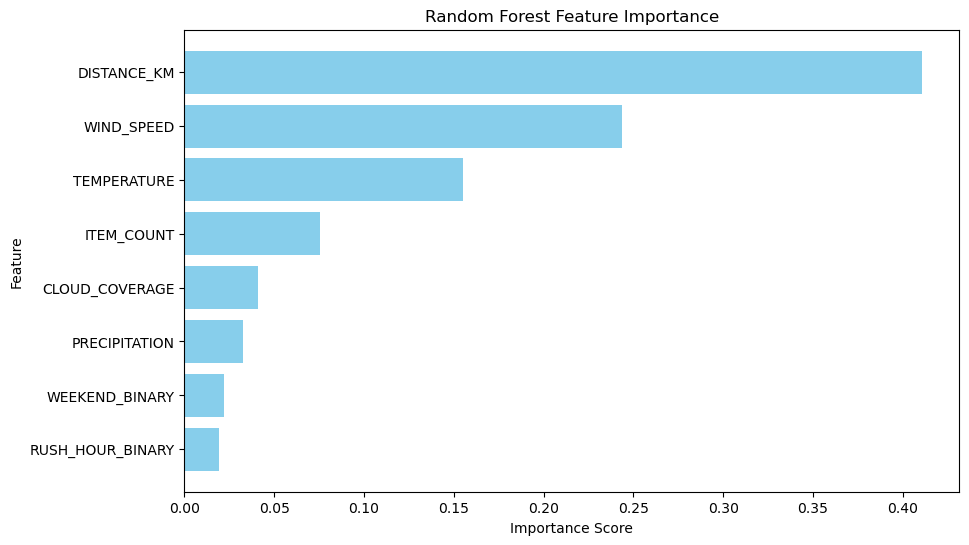

In [43]:
# Feature Importance

# Get the feature importance from the best Random Forest model
feature_importance_rf = best_rf_random.feature_importances_

# Create a DataFrame for the selected features and their importance
feature_importance_df = pd.DataFrame({
    'Feature': selected_features_rf,
    'Importance': feature_importance_rf
})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()

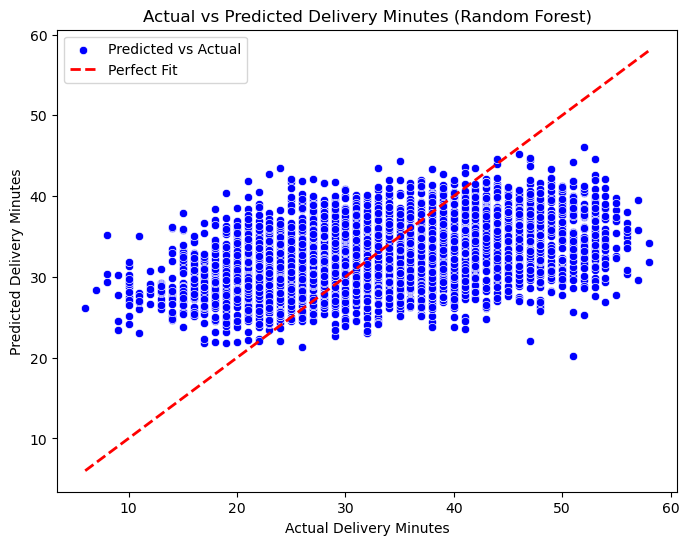

In [44]:
# Predicted vs Actual plot 
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='blue', label='Predicted vs Actual')

# Add a diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')

# Add labels and title
plt.xlabel('Actual Delivery Minutes')
plt.ylabel('Predicted Delivery Minutes')
plt.title('Actual vs Predicted Delivery Minutes (Random Forest)')
plt.legend()

# Show plot
plt.show()

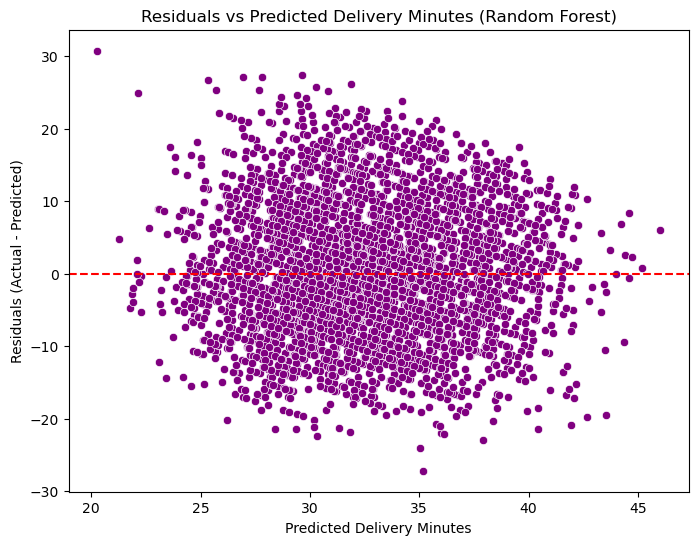

In [45]:
# Calculate residuals
residuals_rf = y_test - y_pred_rf

# Residuals plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_rf, y=residuals_rf, color='purple')

# Add a horizontal line at 0 (perfect prediction)
plt.axhline(0, color='r', linestyle='--')

# Add labels and title
plt.xlabel('Predicted Delivery Minutes')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Delivery Minutes (Random Forest)')

# Show plot
plt.show()

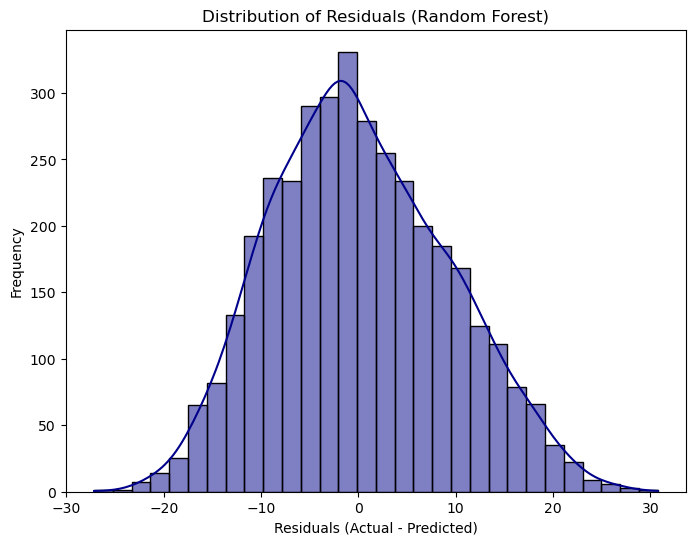

In [46]:
# Distribution of residuals
plt.figure(figsize=(8,6))
sns.histplot(residuals_rf, bins=30, kde=True, color='darkblue')

# Add labels and title
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Random Forest)')

# Show plot
plt.show()

 The residual is the difference between the observed value and the estimated value of the quantity of interest (for example, a sample mean). (Wikipedia)

# Results

In [47]:
from tabulate import tabulate

# Data for the summary table
evaluation_data = [
    ["Ridge Regression", mean_absolute_error(y_test, y_pred_ridge_rfecv), 
     mean_squared_error(y_test, y_pred_ridge_rfecv, squared=False), 
     r2_score(y_test, y_pred_ridge_rfecv)],
    
    ["Lasso Regression", mean_absolute_error(y_test, y_pred_lasso_rfecv), 
     mean_squared_error(y_test, y_pred_lasso_rfecv, squared=False), 
     r2_score(y_test, y_pred_lasso_rfecv)],
    
    ["Tuned XGBoost", xgb_mae, xgb_rmse, xgb_r2],
    
    ["Linear Regression", mean_absolute_error(y_test, y_pred_lr), 
     lr_rmse, lr_r2],
    
    ["Random Forest", mae_rf, rmse_rf, r2_rf]
]

# Define the headers
headers = ["Model", "Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)", "R-squared (R²)"]

# Print the table using tabulate
print(tabulate(evaluation_data, headers=headers, tablefmt="fancy_grid"))

╒═══════════════════╤═════════════════════════════╤══════════════════════════════════╤══════════════════╕
│ Model             │   Mean Absolute Error (MAE) │   Root Mean Squared Error (RMSE) │   R-squared (R²) │
╞═══════════════════╪═════════════════════════════╪══════════════════════════════════╪══════════════════╡
│ Ridge Regression  │                     7.72544 │                          9.4453  │         0.107278 │
├───────────────────┼─────────────────────────────┼──────────────────────────────────┼──────────────────┤
│ Lasso Regression  │                     7.74113 │                          9.46427 │         0.103687 │
├───────────────────┼─────────────────────────────┼──────────────────────────────────┼──────────────────┤
│ Tuned XGBoost     │                     7.24512 │                          8.98196 │         0.192714 │
├───────────────────┼─────────────────────────────┼──────────────────────────────────┼──────────────────┤
│ Linear Regression │                     7.72

**Interpretation:**

Tree based models outperform linear models.

This might be explained byt the following:
1. Tree-based models handle non-linearity better
2. XGBoost and Random Forest detect and utilize feature interactions.
3. Tree-based models are generally more robust to outliers and noisy data.
4. Random forest is a ensemble method hat averages the predictions of multiple decision trees, whereas XGBoost further improves this by using a boosting technique to sequentially train trees.

# Extra: Categorial analysis using XGBoost


After analyzing the results of the models, we decided to check whether changing the target variable from continuous to categorical would improve our analysis. 

It has to be kept in mind that by changing the target variable to categorical, we are no longer aiming to predict the delivery time as precisely as our first goal was. 

We decided to use XGBoost because it had the best R^2 number of the models.

We intend to figure out if it is possible to predict if delivery takes a long (30-35min) or a very long time (+45 minutes).



Selected Features (XGBoost): ['ITEM_COUNT', 'CLOUD_COVERAGE', 'TEMPERATURE', 'WIND_SPEED', 'PRECIPITATION', 'DISTANCE_KM', 'RUSH_HOUR_BINARY', 'WEEKEND_BINARY']

In [48]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, classification_report

# Convert delivery times to categories
bins = [0,  30, 45, 1000]  # Define bins for categories
labels = ['0-30 mins', '30-45 mins', '45+ mins']  # Define corresponding labels

# Apply pd.cut to convert continuous delivery times into categorical variables
y_train_categorical = pd.cut(y_train, bins=bins, labels=labels)
y_test_categorical = pd.cut(y_test, bins=bins, labels=labels)

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the categorical labels to integer values
y_train_encoded = label_encoder.fit_transform(y_train_categorical)
y_test_encoded = label_encoder.transform(y_test_categorical)

# Initialize the XGBoost classifier with default parameters
xgb_model_class = XGBClassifier(random_state=42)

# Perform RFECV for XGBoost
rfecv_xgb_class = RFECV(estimator=xgb_model_class, step=1, cv=5, scoring='accuracy')
rfecv_xgb_class.fit(X_train, y_train_encoded)  # Use encoded target here

# Get the selected features from RFECV
selected_features_xgb_class = X_train.columns[rfecv_xgb_class.support_].tolist()
print(f"Selected Features (XGBoost - Classification): {selected_features_xgb_class}")

# Create datasets with the selected features
X_train_xgb_rfecv_class = X_train[selected_features_xgb_class]
X_test_xgb_rfecv_class = X_test[selected_features_xgb_class]

# Fit the model using the selected features
xgb_model_class.fit(X_train_xgb_rfecv_class, y_train_encoded)

# Make predictions with the best XGBoost model
y_pred_xgb_rfecv_class = xgb_model_class.predict(X_test_xgb_rfecv_class)

# Model evaluation for the tuned XGBoost model
accuracy = accuracy_score(y_test_encoded, y_pred_xgb_rfecv_class)
report = classification_report(y_test_encoded, y_pred_xgb_rfecv_class)

print("XGBoost Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(report)

Selected Features (XGBoost - Classification): ['ITEM_COUNT', 'CLOUD_COVERAGE', 'TEMPERATURE', 'WIND_SPEED', 'PRECIPITATION', 'DISTANCE_KM', 'RUSH_HOUR_BINARY', 'WEEKEND_BINARY']
XGBoost Model Evaluation Metrics:
Accuracy: 0.5458
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.68      0.62      1643
           1       0.52      0.55      0.53      1581
           2       0.37      0.06      0.11       462

    accuracy                           0.55      3686
   macro avg       0.49      0.43      0.42      3686
weighted avg       0.53      0.55      0.52      3686



**Key Insights**

*Class Performance:*
- The model performs relatively well for class 0 (0-30 mins) but struggles significantly with class 2 (45+ mins), with very low recall and F1-score. This indicates that many instances that should be classified as class 2 are likely misclassified as class 0 or class 1.

*Class Imbalance:*
- The distribution of instances among the classes may affect model performance. If class 0 has significantly more instances than class 2, the model might be biased towards predicting class 0.

*Overall Model Effectiveness:*
- An accuracy of about 54.58% suggests the model may not yet be robust enough for practical use, particularly in applications requiring reliable predictions across all categories.



# Extra: Comparison to Wolt's own estimates

In the raw data, Wolt has their own estimations as a feature 'ESTIMATED_DELIVERY_MINUTES'. Thus, so we can se how our models compare to their own analysis.

In [49]:
# Extract actual and estimated delivery times
actual_delivery_times = orders_autumn_2020_df['ACTUAL_DELIVERY_MINUTES']
estimated_delivery_times = orders_autumn_2020_df['ESTIMATED_DELIVERY_MINUTES']



# Calculate MSE
mse = mean_squared_error(actual_delivery_times, estimated_delivery_times)


# Calculate MAE
mae = mean_absolute_error(actual_delivery_times, estimated_delivery_times)


# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R^2
r2 = r2_score(actual_delivery_times, estimated_delivery_times)

# Print results
print(f"Mean Squared Error (MSE): {mse:.4f}")
print("")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 82.1003

Mean Absolute Error (MAE): 7.2537
Root Mean Squared Error (RMSE): 9.0609
R-squared (R²): 0.1824


**Interpretation**

Our analysis is slightly better than WOlT's own analysis thanks to XGBoost.



|  | WOLT | Group 25 |
|----------|----------|----------|
| MAE:   | 7.2537   | 7.2441   |
| RMSE:    | 9.0609   | 8.9820   |
| R^2   | 0.1824   | 0.1927   |

